In [1]:
# input
data = {
    "Metal": ["Mg", "Mg", "Mg", "Zn", "Zn", "Zn"],
    "Env": [ "WT", "EDTA", "mutant", "WT", "EDTA", "mutant"],
    "Data": [
        [0.578499, 0.542396, 0.381796, 0.360098], 
        [0.021922, 0.007694, 0.014063, 0.009998], 
        [0.0581505, 0.0713915, 0.116301, 0.142783],
        [0.5249705, 0.4472905, 0.457213, 0.460178], 
        [0.015733, 0.0158385, 0.177465, 0.176632], 
        [0.040669, 0.0447955, 0.081338, 0.089591],
    ]
}
# output
fig_file = "./fig/rpia_edta_mutant_icp-mass.pdf"

[Text(0.25, 0, 'Mg'), Text(1.4, 0, 'Zn')]

Text(0, 0.5, 'Ratio in mol (ion / protein)')

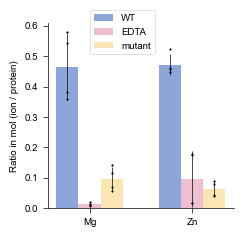

In [19]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

means = [np.mean(d) for d in data["Data"]]
stds = [np.std(d, ddof=1) for d in data["Data"]]

n_metals = 2  # mg, zn
n_envs = 3  # wt, edta, mutant
n_rep = 4
bar_width = 0.25
group_spacing = 0.4
x = np.arange(n_metals) * (n_envs * bar_width + group_spacing)

fig, ax = plt.subplots(figsize=(2.4, 2.4))

for i in range(n_envs):
    bars = ax.bar(
        x + i * bar_width,
        means[i::n_envs],
        bar_width,
        label=data["Env"][i],
        yerr=stds[i::n_envs],
    )
    
    for j, (bx, mean) in enumerate(zip(x + i * bar_width, means[i::n_envs])):
        ax.scatter(
            [bx] * n_rep,
            data["Data"][i + j * n_envs],
            color="black",
            s=1,
        )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(x + bar_width)
ax.set_xticklabels(["Mg", "Zn"])
ax.set_ylabel('Ratio in mol (ion / protein)')
ax.legend(
    loc='upper right',
    bbox_to_anchor=(0.6,1.1)
)
plt.savefig(fig_file, transparent=True, bbox_inches='tight')